In [1]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 3.7 MB/s eta 0:00:00


In [5]:
#mount google drive
from google.colab import drive
import os
drive.mount('/content/drive')
PARQUET_PATH  = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
CHALLENGE_DATA_PATH = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
SUBMISSION_PATH = os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#If running locally instead of colab
DATA_PATH = 'cleaned_data'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

#Final Data cleaning for Task 4.1

In [17]:
df_train = pd.read_parquet(PARQUET_PATH + "/merged_data/combined.parquet")
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_parquet(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.parquet')
df_challenge = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
df_challenge = df_challenge.merge(challenge_transcriptomics, on='participant_id', how='inner')

In [18]:
#drop any d28 HAI columns which are not the target column (HAI_H1N1 A/Victoria/4897/2022_d28)
df_train = df_train.drop(columns=[c for c in df_train.columns if c.endswith('_d28') and c.startswith('HAI') and c != 'HAI_H1N1 A/Victoria/4897/2022_d28'])

#filter out participants who do not have a baseline measurement for H1N1 A/Victoria/4897/2022 at day 0
df_train = df_train[df_train['HAI_H1N1 A/Victoria/4897/2022_d28'].isna() == False]

#filter out columns which are all NaN
df_train = df_train.dropna(axis=1, how='all')

In [19]:
df_train['DELTA'] = df_train['HAI_H1N1 A/Victoria/4897/2022_d28'] - df_train['HAI_H1N1 A/Victoria/4897/2022_d0']
df_train.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d28'], inplace=True)

df_train['DELTA'].value_counts()

,count
DELTA,
0.0,152
1.0,20
2.0,10
-1.0,6
3.0,6
-3.0,4
3.0,3
-2.0,3
4.0,3


In [23]:
df_train

,participant_id,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,...,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,DELTA
3466,2023_UGA.ID_002,Male,Unknown,Georgia,Standard Fluzone,46.0,6.321928,6.321928,2.321928,6.321928,...,6.321928,5.321928,4.321928,5.321928,7.321928,6.321928,6.321928,7.321928,5.321928,0.0
3467,2023_UGA.ID_014,Female,Unknown,Georgia,High Dose Fluzone,68.0,3.321928,3.321928,2.321928,2.321928,...,4.321928,3.321928,4.321928,6.321928,8.321928,3.321928,2.321928,2.321928,6.321928,0.0
3468,2023_UGA.ID_039,Female,Unknown,Georgia,Standard Fluzone,28.0,8.321928,7.321928,6.321928,3.321928,...,8.321928,6.321928,8.321928,9.321928,9.321928,2.321928,2.321928,2.321928,8.321928,0.0
3469,2023_UGA.ID_058,Female,Unknown,Georgia,Standard Fluzone,63.0,4.321928,4.321928,2.321928,2.321928,...,7.321928,5.321928,7.321928,7.321928,8.321928,5.321928,3.321928,2.321928,6.321928,0.0
3470,2023_UGA.ID_065,Female,Unknown,Georgia,Standard Fluzone,30.0,7.321928,8.321928,4.321928,5.321928,...,9.321928,5.321928,8.321928,7.321928,8.321928,4.321928,7.321928,3.321928,9.321928,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,2023_UGA.ID_750,Female,Unknown,Georgia,Standard Fluzone,26.0,4.321928,4.321928,2.321928,2.321928,...,3.321928,2.321928,3.321928,4.321928,7.321928,2.321928,2.321928,2.321928,6.321928,0.0
3680,2023_UGA.ID_751,Male,Unknown,Georgia,Standard Fluzone,29.0,7.321928,7.321928,5.321928,6.321928,...,8.321928,3.321928,4.321928,7.321928,8.321928,2.321928,2.321928,2.321928,5.321928,0.0
3681,2023_UGA.ID_753,Female,Unknown,Georgia,Standard Fluzone,64.0,8.321928,8.321928,7.321928,6.321928,...,9.321928,6.321928,7.321928,8.321928,8.321928,4.321928,4.321928,4.321928,7.321928,1.0
3682,2023_UGA.ID_754,Female,Unknown,Georgia,Standard Fluzone,39.0,6.321928,5.321928,4.321928,2.321928,...,3.321928,2.321928,3.321928,2.321928,5.321928,4.321928,2.321928,2.321928,5.321928,7.0


#Copy relevant data preprocessing for the challenge set:

# Task 4.1

**4.1 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 28

In [ ]:
TARGET_COL = 'HAI_H1N1 A/Victoria/4897/2022_d28'  # task 4.1

## Task 4.1: BASELINE LINNEAR REGRESSION MODEL
Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for H1N1 A/Victoria/4897/2022 at Day 28 post-vaccination.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h2o
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpeegct4lu
  JVM stdout: /tmp/tmpeegct4lu/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpeegct4lu/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 16 days
H2O_cluster_name:,H2O_from_python_unknownUser_i6r3hk
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12.75 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [ ]:
data = h2o.import_file(DATA_PATH + "/merged_data/combined.parquet")

Parse progress: |████████████████████████████████████████████████████████████████| 100%e) 100%


In [ ]:
x = [c for c in data.columns if not c.endswith('_d28') and not c.endswith('_d365')]
y = TARGET_COL
x = [c for c in x if c != y]

In [ ]:
train, test = data.split_frame(ratios=[.8], seed=1234)

In [ ]:
aml = H2OAutoML(max_models=10, seed=1, max_runtime_secs=1200)
aml.train(x=x, y=y, training_frame=train)

AutoML progress: |████
04:42:25.464: _train param, Dropping bad and constant columns: [TRAN_ENSG00000289025_d7, TRAN_ENSG00000294858_d7, TRAN_ENSG00000303447_d7, TRAN_ENSG00000225825_d7, TRAN_ENSG00000290014_d0, TRAN_ENSG00000303447_d0, TRAN_ENSG00000307809_d0, TRAN_ENSG00000290014_d7, TRAN_ENSG00000305628_d7, TRAN_ENSG00000289025_d0, TRAN_ENSG00000307809_d7, TRAN_ENSG00000305628_d0, TRAN_ENSG00000303459_d0, TRAN_ENSG00000224500_d7, TRAN_ENSG00000265046_d7, TRAN_ENSG00000302122_d0, TRAN_ENSG00000301266_d0, TRAN_ENSG00000302122_d7, TRAN_ENSG00000285900_d7, TRAN_ENSG00000294858_d0, TRAN_ENSG00000301266_d7, TRAN_ENSG00000285900_d0, TRAN_ENSG00000304773_d0, TRAN_ENSG00000255256_d7, TRAN_ENSG00000303459_d7, TRAN_ENSG00000304773_d7, TRAN_ENSG00000306942_d7, TRAN_ENSG00000305616_d0, TRAN_ENSG00000304797_d0, TRAN_ENSG00000306978_d0, TRAN_ENSG00000306978_d7, TRAN_ENSG00000305616_d7, TRAN_ENSG00000306942_d0, TRAN_ENSG00000304797_d7, TRAN_ENSG00000196383_d7, TRAN_ENSG00000304303_d7, TRAN_ENSG0000

Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_1_20260429_43940


GLM Model: summary
    family    link      regularization               lambda_search                                                                number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  --------  ---------------------------  ---------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ----------------------------------------------
    gaussian  identity  Ridge ( lambda = 0.003707 )  nlambda = 30, lambda.max = 4.0137, lambda.min = 0.003707, lambda.1se = -1.0  80451                         22                             104                     AutoML_1_20260429_43940_training_py_2_sid_86aa

ModelMetricsRegressionGLM: glm
** Reported on train data. **

MSE: 1.4699727077650446
RMSE: 1.2124243101179737
MAE: 0.8138229276030049
RMSLE: 0.23871344034344555
Mean Residual Deviance: 1.4699727077650446
R^2: 0.3440759232283467
Null degrees of freedom: 111
Residual degrees of freedom: 89
Null deviance: 251.00000000000082
Residual deviance: 164.636943269685
AIC: 408.98954089871785

ModelMetricsRegressionGLM: glm
** Reported on validation data. **

MSE: 0.2574285752908875
RMSE: 0.5073741965166217
MAE: 0.4025764094912615
RMSLE: 0.13327158975403816
Mean Residual Deviance: 0.2574285752908875
R^2: 0.7619235728516093
Null degrees of freedom: 22
Residual degrees of freedom: 0
Null deviance: 29.43750144720517
Residual deviance: 5.9208572316904124
AIC: 82.05987410550338

Scoring History: 
     timestamp            duration          iteration    lambda    predictors    deviance_train       deviance_test        alpha    iterations    training_rmse       training_deviance    training_mae        training_r2           validation_rmse     validation_deviance    validation_mae      validation_r2
---  -------------------  ----------------  -----------  --------  ------------  -------------------  -------------------  -------  ------------  ------------------  -------------------  ------------------  --------------------  ------------------  ---------------------  ------------------  -------------------
     2026-04-29 04:45:55  0.000 sec         2            .4E1      23            0.23164521566256002  1.2406792669556639   0.0      2             1.4796128262884678  2.1892541157173477   1.1016771332321231  0.023121669480705487  1.1138578597369448  1.2406793316977676     0.8559407026348534  -0.1474114798393693
     2026-04-29 04:46:21  26.756 sec        4            .29E1     23            0.22987067164606795  1.226365916578994    0.0
     2026-04-29 04:46:27  32.650 sec        6            .21E1     23            0.2276319998745499   1.2079421142848774   0.0
     2026-04-29 04:46:36  41.575 sec        10           .15E1     23            0.2247507214347828   1.1655821690320765   0.0      10            1.2124243101179737  1.4699727077650446   0.8138229276030049  0.3440759232283467    0.5073741965166217  0.2574285752908875     0.4025764094912615  0.7619235728516093
     2026-04-29 04:46:42  47.599 sec        13           .11E1     23            0.22143292513870533  1.1367806505437414   0.0
     2026-04-29 04:46:49  54.523 sec        16           .82E0     23            0.21759352405253551  1.1008419959239903   0.0
     2026-04-29 04:46:58  1 min  3.760 sec  21           .6E0      23            0.21323462024336817  1.0453929589851454   0.0
     2026-04-29 04:47:05  1 min 10.429 sec  24           .43E0     23            0.20862462120223876  0.9969608052528306   0.0
     2026-04-29 04:47:14  1 min 19.001 sec  28           .32E0     23            0.20375878123742314  0.9354211100954007   0.0
     2026-04-29 04:47:22  1 min 27.475 sec  32           .23E0     23            0.19881111409702268  0.8704807884908148   0.0
---  ---                  ---               ---

In [ ]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                           rmse       mse       mae     rmsle    mean_residual_deviance
GLM_1_AutoML_1_20260429_43940  0.507374  0.257429  0.402576  0.133272                  0.257429
GBM_1_AutoML_1_20260429_43940  0.778923  0.606721  0.612527  0.166531                  0.606721
[2 rows x 6 columns]



In [ ]:
print(aml.leader)

Model Details
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_1_20260429_43940


GLM Model: summary
    family    link      regularization               lambda_search                                                                number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  --------  ---------------------------  ---------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ----------------------------------------------
    gaussian  identity  Ridge ( lambda = 0.003707 )  nlambda = 30, lambda.max = 4.0137, lambda.min = 0.003707, lambda.1se = -1.0  80451                         22                             104                     AutoML_1_20260429_43940_training_py_2_sid_86aa

ModelMetricsRegressionGLM: glm
** Reported on train data. **

MSE: 1.4699727077650446
RMSE: 1.212424310117973

In [ ]:
predictions = aml.leader.predict(test)

results = test[y].cbind(predictions["predict"])
results.columns = ["actual", "predicted"]

# Filter out rows where actual is NaN
results_clean = results[results["actual"].isna() == 0]

print(results_clean.head(20))

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
  actual    predicted
 2.32193      2.52772
 4.32193      5.41739
 2.32193      3.2967
 5.32193      6.58325
 5.32193      3.47766
 2.32193      2.98496
 4.32193      2.74481
 2.32193      2.79079
 2.32193      2.78699
 2.32193      2.54601
 2.32193      2.24908
 2.32193      2.59891
 2.32193      5.30447
 2.32193      2.96387
 2.32193      3.33095
 2.32193      3.07653
 2.32193      2.79828
 2.32193      2.56647
 7.32193      5.02028
 2.32193      2.73286
[20 rows x 2 columns]



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Spearman (results_clean): 0.250  (p-value: 0.1143)


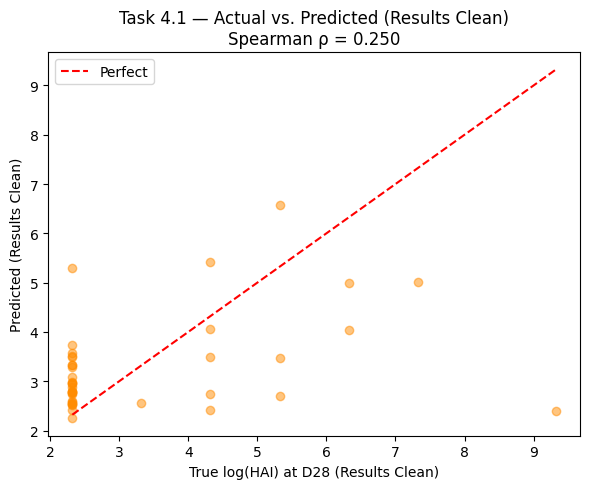

In [ ]:
actual_values = results_clean['actual'].as_data_frame().to_numpy()
predicted_values = results_clean['predicted'].as_data_frame().to_numpy()

rho_results, pval_results = spearmanr(actual_values, predicted_values)
print(f'Spearman (results_clean): {rho_results:.3f}  (p-value: {pval_results:.4f})')

plt.figure(figsize=(6, 5))
plt.scatter(actual_values, predicted_values, alpha=0.5, color='darkorange')
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28 (Results Clean)')
plt.ylabel('Predicted (Results Clean)')
plt.title(f'Task 4.1 — Actual vs. Predicted (Results Clean)\nSpearman ρ = {rho_results:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

#Use AutoML model to predict challenge set

In [ ]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_parquet(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.parquet')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
challenge_data = challenge_data.merge(challenge_transcriptomics, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 109827)


In [ ]:
challenge_hf = h2o.H2OFrame(challenge_data)
y_pred_challenge = aml.leader.predict(challenge_hf).as_data_frame()['predict']

results = pd.DataFrame({
    'participant_id': challenge_data['participant_id'].values,
    'Task_4.1': np.exp2(y_pred_challenge),
})

results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset is missing column 'FLOW_Ab-secreting cells ASC_d0': substituting in a column of NaN
  warnings.warn(w)
/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset is missing column 'FLOW_B cells_d0': substituting in a column of NaN
  warnings.warn(w)
/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset is missing column 'FLOW_CD4 T cells_d0': substituting in a column of NaN
  warnings.warn(w)
/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset is missing column 'FLOW_CD4 Tcn_d0': substituting in a column of NaN
  warnings.warn(w)
/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validation dataset is missing column 'FLOW_CD4 Tem_d0': substituting in a column of NaN
  warnings.warn(w)
/usr/local/lib/python3.12/dist-packages/h2o/job.py:81: UserWarning: Test/Validati

,participant_id,Task_4.1
0,2024_UGA.ID_077,4.336098
1,2024_UGA.ID_086,19.767994
2,2024_UGA.ID_128,36.688057
3,2024_UGA.ID_170,3.989240
4,2024_UGA.ID_179,3.150076
5,2024_UGA.ID_215,6.284622
6,2024_UGA.ID_219,6.470642
7,2024_UGA.ID_275,7.311551
8,2024_UGA.ID_295,10.736039
9,2024_UGA.ID_296,5.658889


In [ ]:
d0 = challenge_data[['participant_id', TARGET_COL.replace('_d28', '_d0')]]
d0[TARGET_COL.replace('_d28', '_d0')] = np.exp2(d0[TARGET_COL.replace('_d28', '_d0')])
d0 = d0.merge(results, on='participant_id', how='inner')
d0


/tmp/ipykernel_14879/874900957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d0[TARGET_COL.replace('_d28', '_d0')] = np.exp2(d0[TARGET_COL.replace('_d28', '_d0')])


,participant_id,HAI_H1N1 A/Victoria/4897/2022_d0,Task_4.1
0,2024_UGA.ID_077,5.0,4.336098
1,2024_UGA.ID_086,20.0,19.767994
2,2024_UGA.ID_128,40.0,36.688057
3,2024_UGA.ID_170,5.0,3.989240
4,2024_UGA.ID_179,5.0,3.150076
5,2024_UGA.ID_215,5.0,6.284622
6,2024_UGA.ID_219,5.0,6.470642
7,2024_UGA.ID_275,10.0,7.311551
8,2024_UGA.ID_295,20.0,10.736039
9,2024_UGA.ID_296,5.0,5.658889


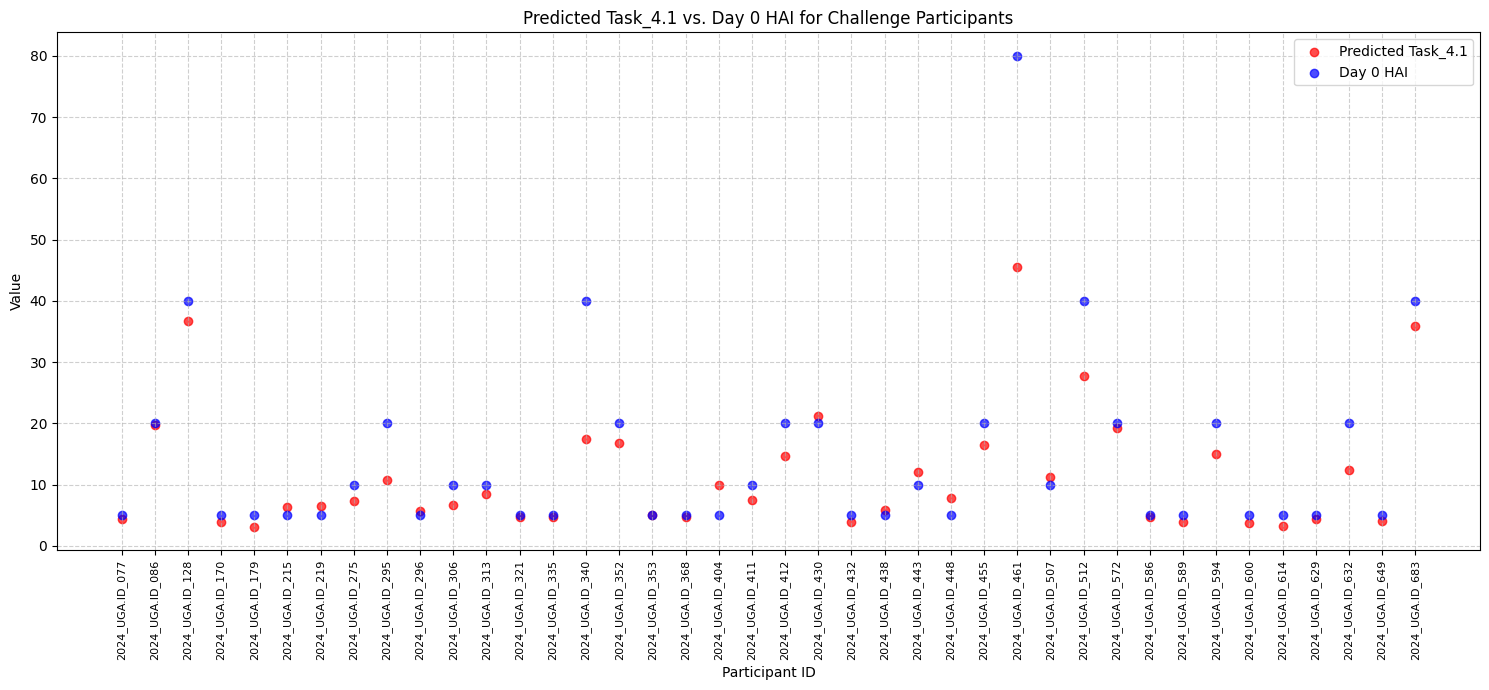

In [ ]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.1 values
plt.scatter(d0['participant_id'], d0['Task_4.1'], color='red', label='Predicted Task_4.1', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(d0['participant_id'], d0['HAI_H1N1 A/Victoria/4897/2022_d0'], color='blue', label='Day 0 HAI', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task_4.1 vs. Day 0 HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#output to csv

results.to_csv(SUBMISSION_PATH + '/task_4_1.csv', index=False)

# Task 4.7: BASELINE LINNEAR REGRESSION MODEL

**4.7 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 365

Since we do not have any d365 info for these participants we will just find some multiplier based on on d28 predictions

In [ ]:
df_4_7 = pd.DataFrame({
    'participant_id': challenge_data['participant_id'].values,
    'Task_4.1': y_pred_challenge,
    'HAI_H1N1 A/Victoria/4897/2022_d0': challenge_data[TARGET_COL.replace('_d28', '_d0')]
})

df_4_7['Task_4.7'] = df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'] + (df_4_7['Task_4.1'] - df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'])*0.1
df_4_7['Task_4.7'] = np.exp2(df_4_7['Task_4.7'])
df_4_7['Task_4.1'] = np.exp2(df_4_7['Task_4.1'])
df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'] = np.exp2(df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'])
df_4_7

,participant_id,Task_4.1,HAI_H1N1 A/Victoria/4897/2022_d0,Task_4.7
0,2024_UGA.ID_077,4.336098,5.0,4.929273
1,2024_UGA.ID_086,19.767994,20.0,19.976677
2,2024_UGA.ID_128,36.688057,40.0,39.655777
3,2024_UGA.ID_170,3.989240,5.0,4.888347
4,2024_UGA.ID_179,3.150076,5.0,4.774250
5,2024_UGA.ID_215,6.284622,5.0,5.115651
6,2024_UGA.ID_219,6.470642,5.0,5.130595
7,2024_UGA.ID_275,7.311551,10.0,9.691722
8,2024_UGA.ID_295,10.736039,20.0,18.793662
9,2024_UGA.ID_296,5.658889,5.0,5.062279


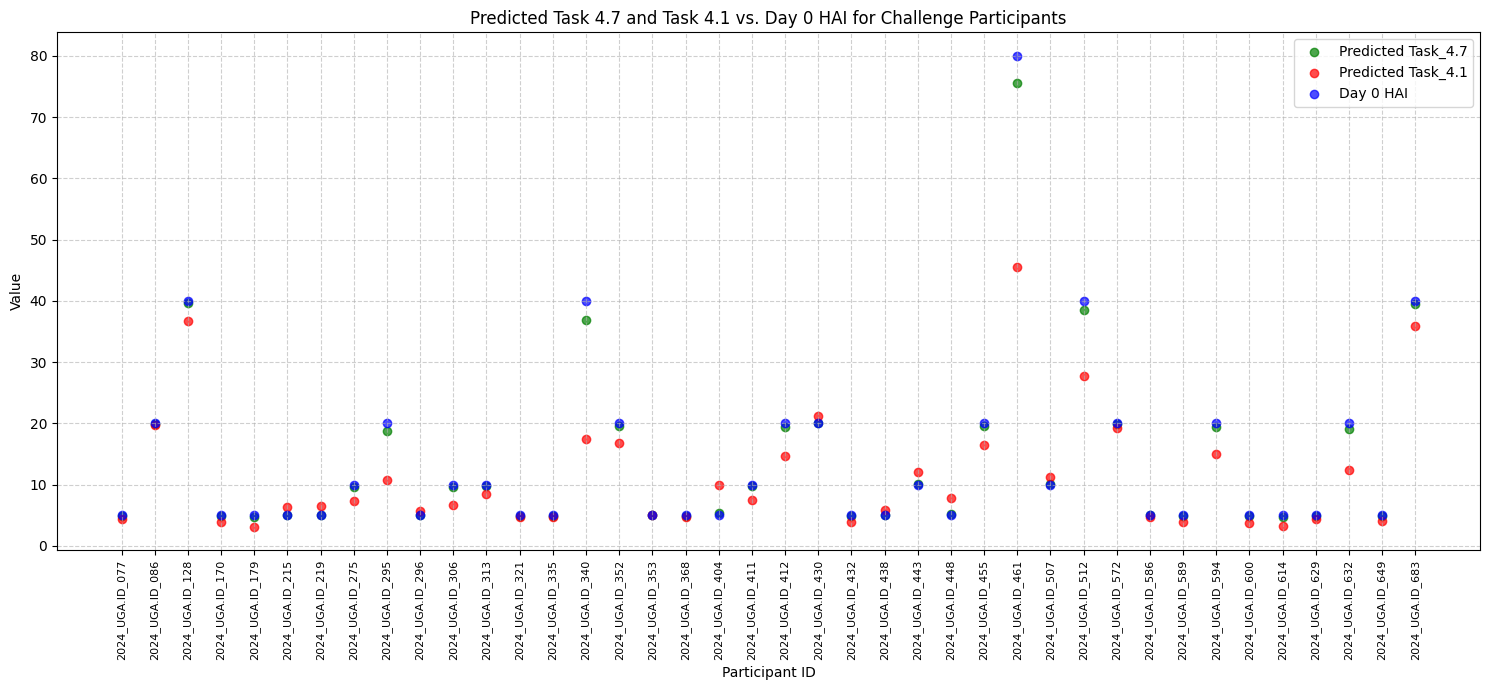

In [ ]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.7 values
plt.scatter(df_4_7['participant_id'], df_4_7['Task_4.7'], color='green', label='Predicted Task_4.7', alpha=0.7)

# Plot predicted Task_4.1 values
plt.scatter(df_4_7['participant_id'], df_4_7['Task_4.1'], color='red', label='Predicted Task_4.1', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(df_4_7['participant_id'], df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'], color='blue', label='Day 0 HAI', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task 4.7 and Task 4.1 vs. Day 0 HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#output to csv
df_4_7.drop(columns=['Task_4.1','HAI_H1N1 A/Victoria/4897/2022_d0'], inplace=True)
df_4_7.to_csv(SUBMISSION_PATH + '/task_4_7.csv', index=False)